In [1]:
1250080179 % 31

2

In [2]:
!pip install imbalanced-learn

In [3]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np

# B1. Tien xu ly du lieu


## 1. Doc du lieu tu tap tin

In [5]:
df_train = pd.read_csv('data/breast-cancer_hard.xls')
df_train.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Kiem tra du lieu null


In [6]:
df_train.shape, df_train.isna().sum()

((569, 32),
 id                         0
 diagnosis                  0
 radius_mean                0
 texture_mean               0
 perimeter_mean             0
 area_mean                  0
 smoothness_mean            0
 compactness_mean           0
 concavity_mean             0
 concave points_mean        0
 symmetry_mean              0
 fractal_dimension_mean     0
 radius_se                  0
 texture_se                 0
 perimeter_se               0
 area_se                    0
 smoothness_se              0
 compactness_se             0
 concavity_se               0
 concave points_se          0
 symmetry_se                0
 fractal_dimension_se       0
 radius_worst               0
 texture_worst              0
 perimeter_worst            0
 area_worst                 0
 smoothness_worst           0
 compactness_worst          0
 concavity_worst            0
 concave points_worst       0
 symmetry_worst             0
 fractal_dimension_worst    0
 dtype: int64)

## 3. Xoa du lieu null neu co (xoa tren dong hoac cot)


In [7]:
df_drop =  df_train.dropna().copy()
df_drop.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 4. Loai bo cac cot du lieu ko dung


In [8]:
df_drop.drop(columns='id', inplace=True)

## 5. Chuyen cac bien dinh tinh


In [9]:
cols_bin = []
cols_mult = []
for col in df_drop.columns:
    if df_drop[col].dtype == object:
        if df_drop[col].nunique() > 2:
            cols_mult.append(col)
        else:
            cols_bin.append(col)
cols_bin, cols_mult


(['diagnosis'], [])

In [10]:
encoder = LabelEncoder()
df_drop['diagnosis'] = encoder.fit_transform(df_drop['diagnosis'])

## 6. Scale du lieu (neu dung thuat toan nhom 2)


In [11]:
X = df_drop.drop(columns='diagnosis')
y = df_drop['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2026)

In [12]:
cols_num = X_train.columns
scaler = StandardScaler()
X_train_scale = X_train.copy()
X_test_scale = X_test.copy()

X_train_scale[cols_num] = scaler.fit_transform(X_train_scale[cols_num])
X_test_scale[cols_num] = scaler.transform(X_test_scale[cols_num])

# B2. Thong ke mo ta


## 1. Thong ke so luong quan sat tren bien quan sat (y)


In [13]:
promoted = df_train['diagnosis'].value_counts()
promoted.index

Index(['B', 'M'], dtype='object', name='diagnosis')

## 2. Truc quan histogram cua bien quan sat (y)


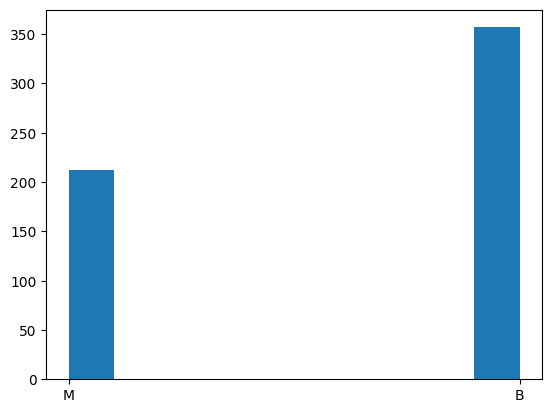

In [14]:
plt.hist(df_train['diagnosis'])
plt.show()

# B3: Xay dung mo hinh


## 1. Chia du lieu thanh 2 tap train va test


In [15]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((426, 30), (143, 30), (426,), (143,))

## 2. Chay mo hinh Classify


In [16]:
lg = LogisticRegression(max_iter=5000, random_state=2026)
lg.fit(X_train_scale, y_train)
lg.score(X_train_scale, y_train), lg.score(X_test_scale, y_test)

(0.9835680751173709, 0.986013986013986)

In [17]:
sgd = SGDClassifier()
sgd.fit(X_train_scale, y_train)
sgd.score(X_train_scale, y_train), sgd.score(X_test_scale, y_test)

(0.9765258215962441, 0.9440559440559441)

In [18]:
mlp = MLPClassifier(max_iter=500)
mlp.fit(X_train_scale, y_train)
mlp.score(X_train_scale, y_train), mlp.score(X_test_scale, y_test)

(0.9976525821596244, 0.9790209790209791)

In [19]:
svc = SVC()
svc.fit(X_train_scale, y_train)
svc.score(X_train_scale, y_train), svc.score(X_test_scale, y_test)

(0.9859154929577465, 0.986013986013986)

# B4: Danh gia mo hinh


## 1. Du doan mo hinh


In [20]:
y_test_pred = lg.predict(X_test_scale)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        82
           1       1.00      0.97      0.98        61

    accuracy                           0.99       143
   macro avg       0.99      0.98      0.99       143
weighted avg       0.99      0.99      0.99       143



In [21]:
y_test_pred = sgd.predict(X_test_scale)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        82
           1       0.93      0.93      0.93        61

    accuracy                           0.94       143
   macro avg       0.94      0.94      0.94       143
weighted avg       0.94      0.94      0.94       143



In [22]:
y_test_pred = mlp.predict(X_test_scale)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98        82
           1       0.98      0.97      0.98        61

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



In [23]:
y_test_pred = svc.predict(X_test_scale)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        82
           1       1.00      0.97      0.98        61

    accuracy                           0.99       143
   macro avg       0.99      0.98      0.99       143
weighted avg       0.99      0.99      0.99       143



## 2. Danh gia mo hinh voi cac chi so Accuracy, Precision, Recall, F1


In [24]:
y_test_pred_lg = lg.predict(X_test_scale)
y_test_pred_sgd = sgd.predict(X_test_scale)
y_test_pred_mlp = mlp.predict(X_test_scale)
y_test_pred_svc = svc.predict(X_test_scale)

In [25]:
print('LogisticRegression')
print(classification_report(y_test, y_test_pred_lg))
print('Accuracy:', lg.score(X_test_scale, y_test))

print('SGDClassifier')
print(classification_report(y_test, y_test_pred_sgd))
print('Accuracy:', sgd.score(X_test_scale, y_test))

print('MLPClassifier')
print(classification_report(y_test, y_test_pred_mlp))
print('Accuracy:', mlp.score(X_test_scale, y_test))

print('SVC')
print(classification_report(y_test, y_test_pred_svc))
print('Accuracy:', svc.score(X_test_scale, y_test))


LogisticRegression
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        82
           1       1.00      0.97      0.98        61

    accuracy                           0.99       143
   macro avg       0.99      0.98      0.99       143
weighted avg       0.99      0.99      0.99       143

Accuracy: 0.986013986013986
SGDClassifier
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        82
           1       0.93      0.93      0.93        61

    accuracy                           0.94       143
   macro avg       0.94      0.94      0.94       143
weighted avg       0.94      0.94      0.94       143

Accuracy: 0.9440559440559441
MLPClassifier
              precision    recall  f1-score   support

           0       0.98      0.99      0.98        82
           1       0.98      0.97      0.98        61

    accuracy                           0.98       143
   macro avg       0.98 

## 3. Truc quan hoa Confusion matrix


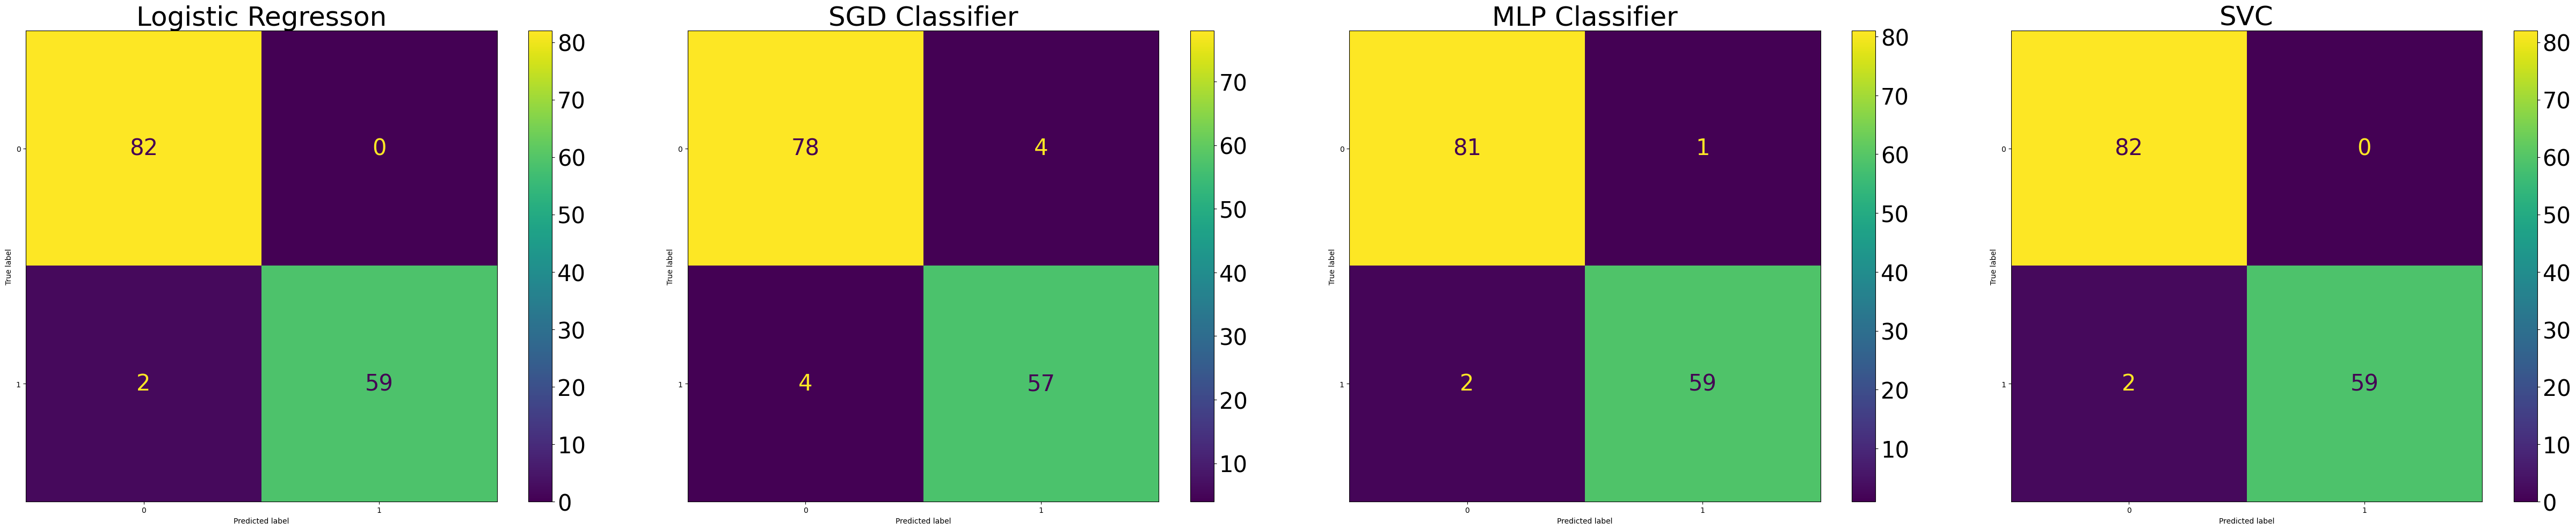

In [26]:
models = {
    'Logistic Regresson': lg,
    'SGD Classifier': sgd,
    'MLP Classifier': mlp,
    'SVC': svc
}

fig, axes = plt.subplots(ncols = 4, figsize = (50, 10))
plt.rcParams['font.size'] = 30

for i, name in enumerate(models):
    ConfusionMatrixDisplay.from_estimator(models[name], X_test_scale, y_test, ax=axes[i])
    axes[i].set_title(name)
plt.tight_layout()
plt.show()


## 4. Ket luan mo hinh


In [27]:
scores = {
    'LogisticRegression': lg.score(X_test_scale, y_test),
    'SGDClassifier': sgd.score(X_test_scale, y_test),
    'MLPClassifier': mlp.score(X_test_scale, y_test),
    'SVC': svc.score(X_test_scale, y_test)
}

best_model = max(scores, key=scores.get)
print('Mo hinh tot nhat theo Accuracy:', best_model)
print('Accuracy:', scores[best_model])


Mo hinh tot nhat theo Accuracy: LogisticRegression
Accuracy: 0.986013986013986
